# Multi Agents - 코드 리뷰 시스템
LangGraph를 활용하여 여러 에이전트가 병렬로 실행되고 결과를 집계하는 코드 리뷰 시스템을 구현합니다.



## 구성
1. **코드 분석 에이전트**: 코드 구조와 로직 파악
2. **버그 검사 에이전트**: 잠재적 버그와 오류 찾기
3. **스타일 검사 에이전트**: 코딩 컨벤션 및 스타일 확인
4. **성능 분석 에이전트**: 성능 이슈 및 최적화 제안
5. **통합 리포트 에이전트**: 모든 리뷰 결과 종합


## 학습 목표
- 병렬 실행 (parallel execution): 여러 에이전트 동시 실행
- 결과 집계 (aggregation): 각 에이전트 결과를 모아서 처리
- 독립적 작동: 각 에이전트가 서로 의존하지 않고 실행


## 1. LLM 초기화


In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    keep_alive="5m"
)

## 2. 상태 정의 (State Management)

병렬 실행을 위한 상태 구조를 정의합니다. `Annotated`와 `add` 연산자를 사용하여 각 에이전트의 결과를 리스트에 집계합니다.


In [4]:
from typing import TypedDict, List, Annotated
from operator import add

class ReviewState(TypedDict):
    """
    코드 리뷰 시스템의 상태를 정의하는 클래스
    """
    code: str
    reviews: Annotated[List[str], add]  # add 연산자로 자동 집계
    final_report: str



## 3. 병렬 실행 에이전트 정의

각 에이전트는 독립적으로 코드를 분석하고, 결과를 `reviews` 리스트에 추가합니다.


### 3.1 코드 분석 에이전트


In [5]:
from langchain_core.messages import HumanMessage, SystemMessage

def code_analysis_agent(state: ReviewState) -> dict:
    """
    코드의 구조와 로직을 분석하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 코드 구조 분석 전문가입니다.
            다음 관점에서 코드를 분석하세요:
            - 전체적인 구조와 설계 패턴
            - 함수/클래스의 역할과 책임
            - 코드의 가독성과 유지보수성
            - 모듈화 수준

            간결하고 명확하게 분석 결과를 제공하세요."""),
        HumanMessage(content=f"다음 코드를 분석하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[코드 구조 분석]\n{response.content}"
    
    print("[코드 분석 에이전트] 분석 완료")
    
    return {
        "reviews": [review]  # 리스트로 반환하여 자동 집계
    }


### 3.2 버그 검사 에이전트


In [6]:
def bug_detection_agent(state: ReviewState) -> dict:
    """
    잠재적 버그와 오류를 찾는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 버그 탐지 전문가입니다.
            다음 관점에서 코드를 검사하세요:
            - 논리적 오류 가능성
            - 예외 처리 누락
            - Null/Undefined 참조 위험
            - 경계 조건 처리
            - 리소스 누수 가능성

            발견된 문제와 해결 방안을 제시하세요."""),
        HumanMessage(content=f"다음 코드에서 버그를 찾으세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[버그 검사]\n{response.content}"
    
    print("[버그 검사 에이전트] 검사 완료")
    
    return {
        "reviews": [review]
    }


### 3.3 스타일 검사 에이전트


In [7]:
def style_check_agent(state: ReviewState) -> dict:
    """
    코딩 컨벤션과 스타일을 검사하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 코딩 스타일 전문가입니다.
            다음 관점에서 코드를 검사하세요:
            - 네이밍 컨벤션 (변수, 함수, 클래스명)
            - 코드 포맷팅 (들여쓰기, 줄바꿈)
            - 주석의 적절성
            - 코드 일관성
            - 베스트 프랙티스 준수 여부

            개선 사항을 구체적으로 제안하세요."""),
        HumanMessage(content=f"다음 코드의 스타일을 검사하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[스타일 검사]\n{response.content}"
    
    print("[스타일 검사 에이전트] 검사 완료")
    
    return {
        "reviews": [review]
    }


### 3.4 성능 분석 에이전트


In [8]:
def performance_analysis_agent(state: ReviewState) -> dict:
    """
    성능 이슈를 분석하고 최적화 방안을 제안하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 성능 최적화 전문가입니다.
            다음 관점에서 코드를 분석하세요:
            - 시간 복잡도와 공간 복잡도
            - 불필요한 연산이나 중복 코드
            - 메모리 사용 효율성
            - 알고리즘 최적화 가능성
            - 병목 지점

            구체적인 최적화 방안을 제시하세요."""),
        HumanMessage(content=f"다음 코드의 성능을 분석하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[성능 분석]\n{response.content}"
    
    print("[성능 분석 에이전트] 분석 완료")
    
    return {
        "reviews": [review]
    }


## 4. 결과 집계 에이전트

모든 병렬 에이전트의 결과를 받아 통합 리포트를 생성합니다.


In [10]:
def aggregation_agent(state: ReviewState) -> dict:
    """
    모든 리뷰 결과를 종합하여 최종 리포트를 생성하는 에이전트
    """
    reviews = state["reviews"]
    
    # 모든 리뷰 결과를 하나의 문자열로 결합
    all_reviews = "\n\n".join(reviews)
    
    messages = [
        SystemMessage(content="""
            당신은 시니어 코드 리뷰어입니다.
            여러 전문가들의 리뷰 결과를 받았습니다. 이를 종합하여:
            1. 주요 발견 사항 요약
            2. 우선순위별 개선 사항 정리
            3. 전체적인 코드 품질 평가
            4. 구체적인 액션 아이템 제시

            명확하고 실행 가능한 최종 리포트를 작성하세요."""),
        HumanMessage(content=f"""
                     다음은 각 전문가들의 리뷰입니다:
                     
                     {all_reviews}
                     
                     이를 종합하여 최종 리포트를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    final_report = response.content
    
    print("[통합 리포트 에이전트] 최종 리포트 생성 완료")
    
    return {
        "final_report": final_report
    }


## 5. 그래프 구성 (병렬 실행)

여러 에이전트가 동시에 실행되도록 그래프를 구성합니다.

### 그래프 구조
```
                    시작
                     |
                     v
         +-----------+-----------+
         |           |           |
         v           v           v
  코드 분석    버그 검사    스타일 검사
         |           |           |
         +-----+-----+-----------+
               |           |
               v           v
          성능 분석   (병렬 실행)
               |
               v
          통합 리포트
               |
               v
             종료
```


In [12]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ReviewState)

# 병렬 실행될 노드들 추가
workflow.add_node("code_analysis", code_analysis_agent)
workflow.add_node("bug_detection", bug_detection_agent)
workflow.add_node("style_check", style_check_agent)
workflow.add_node("performance_analysis", performance_analysis_agent)

# 결과 집계 노드 추가
workflow.add_node("aggregation", aggregation_agent)

# 시작점 설정 - 4개의 에이전트로 동시 분기
workflow.set_entry_point("code_analysis")
workflow.set_entry_point("bug_detection")
workflow.set_entry_point("style_check")
workflow.set_entry_point("performance_analysis")

# 모든 병렬 에이전트에서 집계 에이전트로 연결
workflow.add_edge("code_analysis", "aggregation")
workflow.add_edge("bug_detection", "aggregation")
workflow.add_edge("style_check", "aggregation")
workflow.add_edge("performance_analysis", "aggregation")

# 집계 에이전트에서 종료
workflow.add_edge("aggregation", END)

# 그래프 컴파일
app = workflow.compile()


## 6. 그래프 시각화 (선택사항)


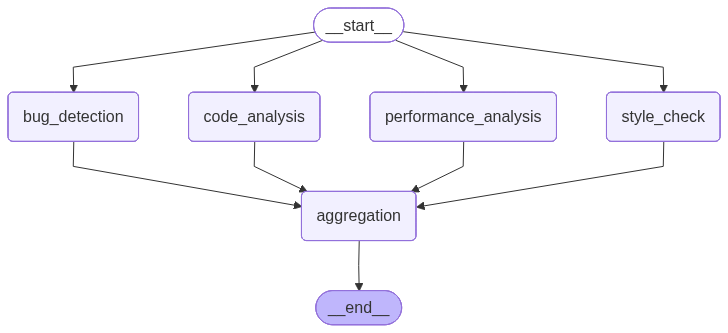

In [13]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7. 테스트 예제

실제 코드를 리뷰하는 예제입니다.


### 7.1 테스트 코드 준비


In [14]:
# 리뷰할 샘플 코드 (의도적으로 개선 여지가 있는 코드)
sample_code = """
def find_duplicates(list):
    result = []
    for i in range(len(list)):
        for j in range(len(list)):
            if i != j and list[i] == list[j]:
                if list[i] not in result:
                    result.append(list[i])
    return result

def calculate_average(numbers):
    sum = 0
    for n in numbers:
        sum = sum + n
    avg = sum / len(numbers)
    return avg

class userManager:
    def __init__(self):
        self.users = []
    
    def add_user(self, name, age):
        self.users.append({'name': name, 'age': age})
    
    def get_user(self, name):
        for user in self.users:
            if user['name'] == name:
                return user
        return None
"""

print("샘플 코드가 준비되었습니다.")


샘플 코드가 준비되었습니다.


### 7.2 코드 리뷰 실행


In [15]:
# 초기 상태 생성
initial_state = {
    "code": sample_code,
    "reviews": [],
    "final_report": ""
}

# 그래프 실행 (병렬 실행)
result = app.invoke(initial_state)

/Users/gyoungwon-cho/dev/github/course_LLM/3. LangChain/2. multi_agents/.venv/lib/python3.13/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=f769b7ee-ec1d-4918-a66a-084522670ef9; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=5d901032-1077-4a6a-8f32-5fa95635aee1; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=ae89cd3b-bd46-43e5-bf3d-f2011d56fc9b; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=b9ee95a7-43f5-4ba9-998c-6eb16fe04783; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=9cebe950-5373-4a79-b205-8281c04621a3; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=abbcbe0a-67ad-4d1d-afce-c

[스타일 검사 에이전트] 검사 완료


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=853e51a5-3ac9-4b6b-9e32-03b0b1f45dc4; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=2e95e248-e9cd-42cc-8d7e-4fbdbb702316; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=2e95e248-e9cd-42cc-8d7e-4fbdbb702316; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=f68e440b-b3b8-489e-b7ab-a2ee067239ab


[코드 분석 에이전트] 분석 완료


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=abbcbe0a-67ad-4d1d-afce-cc50c37ae290; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=4c32f39b-ac53-4339-a634-ebc017ed5c46; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=4c32f39b-ac53-4339-a634-ebc017ed5c46; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=9cebe950-5373-4a79-b205-8281c04621a3


...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=3b57b8ce-d046-40c4-8e21-11fbf201b7f5; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=eb6418d7-c746-4876-9199-5d82b6d0c8d2; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=eb6418d7-c746-4876-9199-5d82b6d0c8d2; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=0db88816-9953-4ae7-847a-659902544d61


[버그 검사 에이전트] 검사 완료


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=3113dd0f-21a1-4d96-a23c-51b7a2357c80; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=1b2f296b-3af6-44f5-843c-0605ff379893; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=1b2f296b-3af6-44f5-843c-0605ff379893; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=9a4dfc2c-e047-4d19-ba36-b33e9fe34b4b; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=5a9ebaa9-be9f-48c1-8aed-e73961f47385; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=d87912eb-3e05-4fc5-b028-f6dc4a44c0d6


[통합 리포트 에이전트] 최종 리포트 생성 완료


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=d87912eb-3e05-4fc5-b028-f6dc4a44c0d6; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=5ec6f30f-b1ad-4aea-9b59-c27267d2e88d; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=5ec6f30f-b1ad-4aea-9b59-c27267d2e88d; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=5a9ebaa9-be9f-48c1-8aed-e73961f47385; trace=f769b7ee-ec1d-4918-a66a-084522670ef9,id=f769b7ee-ec1d-4918-a66a-084522670ef9


### 7.3 개별 리뷰 결과 확인


In [16]:
for i, review in enumerate(result["reviews"], 1):
    print(f"\n리뷰 {i}:")
    print("-" * 80)
    print(review)
    print()



리뷰 1:
--------------------------------------------------------------------------------
[버그 검사]
## 코드 검토 결과 및 문제점

제공된 코드를 버그 탐지 전문가의 관점에서 검토한 결과 다음과 같은 문제점들을 발견했습니다. 각 문제점은 발견된 문제점, 발생 가능한 영향, 그리고 해결 방안을 제시합니다.

**1. `find_duplicates` 함수:**

* **문제점:**
    * **논리적 오류 가능성:** 중복된 값을 찾는 로직 자체는 정확하지만, `i != j` 조건이 항상 정확한 결과를 보장하지 않습니다. 특히 `i`와 `j`가 같은 인덱스에 있을 경우 (예: `list[0] == list[0]`) `False`가 반환되어 중복된 값이 탐지되지 않을 수 있습니다.
    * **성능 문제:**  중첩 루프를 사용하여 모든 쌍의 요소를 비교하므로, 리스트의 크기가 커질수록 시간 복잡도가 O(n^2)로 증가합니다. 이는 매우 큰 리스트에서 성능 저하를 유발할 수 있습니다.
* **발생 가능한 영향:**  중복된 값이 제대로 탐지되지 않아 잘못된 결과가 반환될 수 있습니다.
* **해결 방안:**
    * **중첩 루프 제거:**  중복된 값을 탐지하기 위해 Set 자료구조를 사용하면 O(n)의 시간 복잡도로 더 효율적으로 해결할 수 있습니다.
    * **Set 사용:**  Set은 중복된 값을 허용하지 않으므로, 각 요소가 Set에 있는지 확인하여 중복을 제거할 수 있습니다.
    * **예시:**
    ```python
    def find_duplicates(list):
        seen = set()
        result = []
        for item in list:
            if item in seen:
                if item not in result:
                    result.appe

### 7.4 통합 리포트 확인


In [17]:
print(result["final_report"])

## 코드 품질 검토 보고서

**작성일:** 2023년 10월 27일

**작성자:** AI 코드 분석 시스템

**대상:** 개발팀

**목표:** 제공된 코드의 품질을 평가하고 개선 사항을 제시하여 코드의 가독성, 유지보수성, 효율성을 향상시키는 것을 목표로 합니다.

**1. 요약**

제공된 코드는 기본적인 기능 구현을 위한 것으로, 코드 스타일, 가독성, 효율성 측면에서 개선의 여지가 있습니다.  주요 개선 사항은 다음과 같습니다.

*   **코드 스타일:** 일관성 없는 네이밍, 줄바꿈, 공백 등으로 인해 코드의 가독성이 저하됩니다.
*   **가독성:** 주석 부족으로 코드의 의도를 파악하기 어렵습니다.
*   **효율성:**  `find_duplicate_elements` 함수는 중복된 값을 찾는 데 있어 비효율적인 알고리즘을 사용합니다.
*   **예외 처리:** `compute_average_value` 함수에서 빈 리스트를 처리하지 않아 `ZeroDivisionError`가 발생할 수 있습니다.

**2. 상세 평가**

| 항목             | 평가 결과       | 개선 제안                                                                                                                                                                                                                                                                                                                                                                                                                                          